# EDA: UK Ford used-car listings



In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd() if (Path.cwd() / 'data/raw/ford.csv').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / 'code/datasets'))
from prepare_data import load, clean, CATEGORICAL, NUMERIC
raw = load()
print('Raw shape:', raw.shape)
raw.head()

Raw shape: (17965, 9)


,model,year,price,transmission,mileage,fuel_type,tax,mpg,engine_size
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [2]:
raw.describe(include='all')

,model,year,price,transmission,mileage,fuel_type,tax,mpg,engine_size
count,17965,17965.000000,17965.000000,17965,17965.000000,17965,17965.000000,17965.000000,17965.000000
unique,23,NaN,NaN,3,NaN,5,NaN,NaN,NaN
top,Fiesta,NaN,NaN,Manual,NaN,Petrol,NaN,NaN,NaN
freq,6557,NaN,NaN,15517,NaN,12178,NaN,NaN,NaN
mean,NaN,2016.866574,12279.756415,NaN,23363.630504,NaN,113.334539,57.906991,1.350827
std,NaN,2.050346,4741.382606,NaN,19472.114690,NaN,62.010438,10.125977,0.432371
min,NaN,1996.000000,495.000000,NaN,1.000000,NaN,0.000000,20.800000,0.000000
25%,NaN,2016.000000,8999.000000,NaN,9987.000000,NaN,30.000000,52.300000,1.000000
50%,NaN,2017.000000,11291.000000,NaN,18243.000000,NaN,145.000000,58.900000,1.200000
75%,NaN,2018.000000,15299.000000,NaN,31064.000000,NaN,145.000000,65.700000,1.500000


In [3]:
print('Exact duplicates:', raw.duplicated().sum())
print('Future years:', int((raw.year > 2020).sum()))
print('Zero engine size:', int((raw.engine_size == 0).sum()))
df = clean(raw)
print('Clean shape:', df.shape)
df.isna().sum()

Exact duplicates: 154
Future years: 1
Zero engine size: 51
Clean shape: (17811, 9)


model            0
year             1
price            0
transmission     0
mileage          0
fuel_type        0
tax              0
mpg              0
engine_size     51
dtype: int64

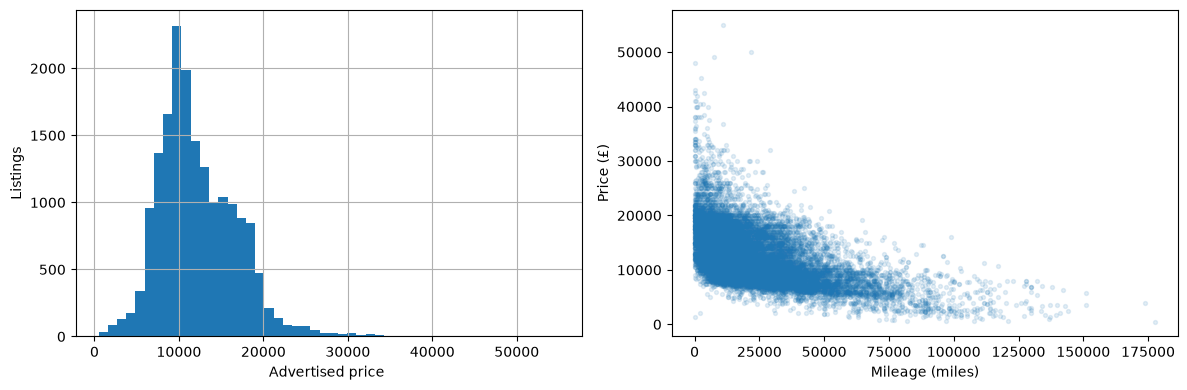

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.price.hist(bins=50, ax=axes[0]); axes[0].set(xlabel='Advertised price ', ylabel='Listings')
axes[1].scatter(df.mileage, df.price, alpha=0.12, s=8); axes[1].set(xlabel='Mileage (miles)', ylabel='Price (£)')
plt.tight_layout(); plt.show()

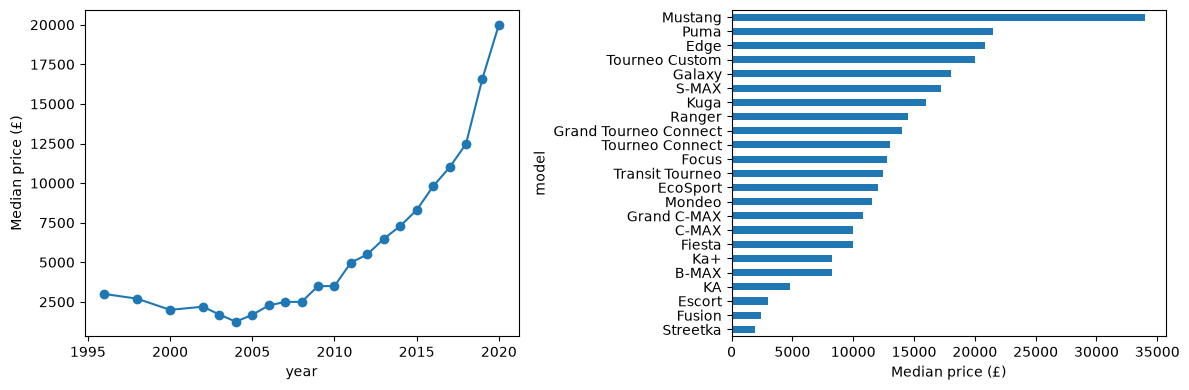

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.groupby('year').price.median().plot(ax=axes[0], marker='o'); axes[0].set(ylabel='Median price (£)')
df.groupby('model').price.median().sort_values().plot.barh(ax=axes[1]); axes[1].set(xlabel='Median price (£)')
plt.tight_layout(); plt.show()

In [17]:
data = raw.copy()
x = data.drop(columns= "price")
duplicate_rows = x[x.duplicated(keep=False)]
duplicate_rows.sort_values(list(x.columns))  

,model,year,transmission,mileage,fuel_type,tax,mpg,engine_size
8480,B-MAX,2013,Manual,31472,Petrol,30,57.7,1.0
9406,B-MAX,2013,Manual,31472,Petrol,30,57.7,1.0
10224,B-MAX,2014,Manual,17441,Diesel,20,68.9,1.5
10272,B-MAX,2014,Manual,17441,Diesel,20,68.9,1.5
17607,B-MAX,2017,Automatic,5000,Petrol,145,44.1,1.6
...,...,...,...,...,...,...,...,...
13451,S-MAX,2019,Manual,9544,Diesel,145,54.3,2.0
8262,S-MAX,2019,Semi-Auto,8998,Diesel,145,51.4,2.0
9046,S-MAX,2019,Semi-Auto,8998,Diesel,145,51.4,2.0
9233,Tourneo Connect,2016,Manual,21026,Diesel,30,64.2,1.5


In [6]:
train = pd.read_csv(ROOT / 'data/processed/train.csv')
test = pd.read_csv(ROOT / 'data/processed/test.csv')
train_keys = set(pd.util.hash_pandas_object(train[CATEGORICAL + NUMERIC], index=False))
test_keys = set(pd.util.hash_pandas_object(test[CATEGORICAL + NUMERIC], index=False))
print('Train/test:', len(train), len(test))
json.loads((ROOT / 'models/metrics.json').read_text())

Train/test: 14244 3567


{'mae': 832.6959228515625,
 'rmse': 1203.362840127615,
 'r2': 0.9348896145820618,
 'baseline_mae': 3609.5149985982616,
 'mae_improvement_pct': 76.93053157626618}

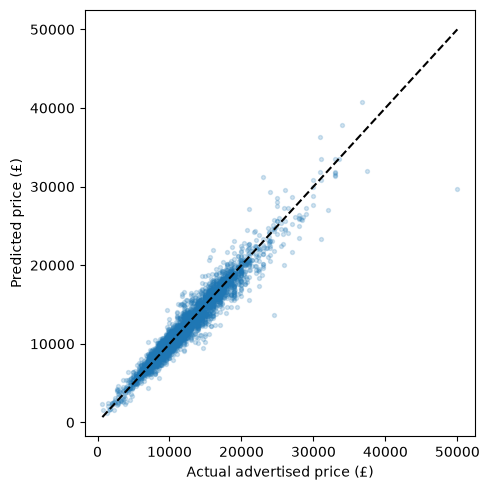

In [7]:
import numpy as np
import onnxruntime as ort
model = ort.InferenceSession(str(ROOT / 'models/model.onnx'), providers=['CPUExecutionProvider'])
inputs = {c: test[c].fillna('').to_numpy(dtype=object).reshape(-1, 1) for c in CATEGORICAL}
inputs.update({c: test[c].to_numpy(dtype=np.float32).reshape(-1, 1) for c in NUMERIC})
pred = model.run(None, inputs)[0].ravel()
plt.figure(figsize=(5, 5)); plt.scatter(test.price, pred, alpha=.2, s=8)
plt.plot([test.price.min(), test.price.max()], [test.price.min(), test.price.max()], 'k--')
plt.xlabel('Actual advertised price (£)'); plt.ylabel('Predicted price (£)'); plt.tight_layout(); plt.show()